In [3]:
%pip install ucimlrepo

  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# id=849 is the Tetouan City power consumption dataset
tetouan = fetch_ucirepo(id=849)
df = pd.concat([tetouan.data.features, tetouan.data.targets], axis=1)

df.to_csv('../data/tetouan_raw.csv', index=False)
print("Saved shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Saved shape: (52416, 9)
Columns: ['DateTime', 'Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [5]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
from pathlib import Path

tetouan = fetch_ucirepo(id=849)

# ucimlrepo splits features/targets; recombine (DateTime handling varies by version)
if getattr(tetouan.data, "original", None) is not None:
    df_raw = tetouan.data.original.copy()
else:
    df_raw = pd.concat([tetouan.data.ids, tetouan.data.features, tetouan.data.targets], axis=1)

print(df_raw.shape)
print(df_raw.columns.tolist())
print(df_raw.head(3))

Path("data").mkdir(exist_ok=True)
df_raw.to_csv("data/tetouan_raw.csv", index=False)
print("Saved to data/tetouan_raw.csv")

(52416, 9)
['DateTime', 'Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']
        DateTime  Temperature  Humidity  Wind Speed  general diffuse flows  \
0  1/1/2017 0:00        6.559      73.8       0.083                  0.051   
1  1/1/2017 0:10        6.414      74.5       0.083                  0.070   
2  1/1/2017 0:20        6.313      74.5       0.080                  0.062   

   diffuse flows  Zone 1 Power Consumption  Zone 2  Power Consumption  \
0          0.119               34055.69620                16128.87538   
1          0.085               29814.68354                19375.07599   
2          0.100               29128.10127                19006.68693   

   Zone 3  Power Consumption  
0                20240.96386  
1                20131.08434  
2                19668.43373  
Saved to data/tetouan_raw.csv


In [6]:
df = pd.read_csv("data/tetouan_raw.csv")

# Normalise column names (dataset uses inconsistent spacing/casing across versions)
df.columns = [c.strip() for c in df.columns]
dt_col = [c for c in df.columns if c.lower().replace(" ", "") == "datetime"][0]
zone_cols = [c for c in df.columns if "power" in c.lower() or "consumption" in c.lower()]
print("DateTime col:", dt_col, "| Zone cols:", zone_cols)
assert len(zone_cols) == 3

df[dt_col] = pd.to_datetime(df[dt_col])
df = df.set_index(dt_col).sort_index()

# 10-min → hourly (mean, same as UCI pipeline)
df_hourly = df.resample("h").mean()
df_hourly["Total_Consumption"] = df_hourly[zone_cols].sum(axis=1)

print("Hourly shape:", df_hourly.shape)
print("Date range:", df_hourly.index.min(), "→", df_hourly.index.max())
print("Missing values:\n", df_hourly.isna().sum())

# Same gap handling as UCI: interpolate short gaps
df_hourly = df_hourly.interpolate(method="time", limit=6)
df_hourly.to_csv("data/tetouan_hourly.csv")

DateTime col: DateTime | Zone cols: ['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']
Hourly shape: (8736, 9)
Date range: 2017-01-01 00:00:00 → 2017-12-30 23:00:00
Missing values:
 Temperature                  0
Humidity                     0
Wind Speed                   0
general diffuse flows        0
diffuse flows                0
Zone 1 Power Consumption     0
Zone 2  Power Consumption    0
Zone 3  Power Consumption    0
Total_Consumption            0
dtype: int64


In [7]:
n = len(df_hourly)
train_end, val_end = int(n * 0.70), int(n * 0.85)
train, val, test = df_hourly.iloc[:train_end], df_hourly.iloc[train_end:val_end], df_hourly.iloc[val_end:]
print(f"Train: {len(train)} ({train.index.min().date()} → {train.index.max().date()})")
print(f"Val:   {len(val)} ({val.index.min().date()} → {val.index.max().date()})")
print(f"Test:  {len(test)} ({test.index.min().date()} → {test.index.max().date()})")

Train: 6115 (2017-01-01 → 2017-09-12)
Val:   1310 (2017-09-12 → 2017-11-06)
Test:  1311 (2017-11-06 → 2017-12-30)


In [8]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

TARGET = "Total_Consumption"
WINDOW = 24

scaler = MinMaxScaler()
train_s = scaler.fit_transform(train[[TARGET]])   # fit on train only
val_s   = scaler.transform(val[[TARGET]])
test_s  = scaler.transform(test[[TARGET]])

def make_windows(arr, window=WINDOW):
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i-window:i])
        y.append(arr[i])
    return np.array(X), np.array(y)

X_train, y_train = make_windows(train_s)
X_val, y_val     = make_windows(val_s)
X_test, y_test   = make_windows(test_s)
print(X_train.shape, X_val.shape, X_test.shape)

(6091, 24, 1) (1286, 24, 1) (1287, 24, 1)


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42); np.random.seed(42)

model = Sequential([
    LSTM(64, input_shape=(WINDOW, 1)),   # ← match UCI: units, layers
    Dropout(0.2),                         # ← match UCI
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")

es = EarlyStopping(patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=50, batch_size=32, callbacks=[es], verbose=1)

C:\Users\Saeed SSA\SmartGrid-Dissertation\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0248 - val_loss: 0.0055
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0076 - val_loss: 0.0043
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0055 - val_loss: 0.0030
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0047 - val_loss: 0.0024
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0040 - val_loss: 0.0020
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0038 - val_loss: 0.0019
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0035 - val_loss: 0.0020
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0030 - val_loss: 0.0020
Epoch 9/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0028 - val_loss: 0.0014
Epoch 10/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 11/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0023 - val_loss: 0.0010
Epoch 12/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def inv(a): return scaler.inverse_transform(a.reshape(-1, 1)).flatten()

y_true = inv(y_test)
y_lstm = inv(model.predict(X_test, verbose=0))
y_naive = inv(X_test[:, -1, 0])          # previous hour
y_ma    = inv(X_test.mean(axis=1).flatten())  # 24h moving average

def metrics(y_t, y_p, name):
    mae  = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100
    nmae = mae / y_t.mean() * 100
    print(f"{name:8s} MAE: {mae:10.2f}  RMSE: {rmse:10.2f}  MAPE: {mape:5.2f}%  nMAE: {nmae:5.2f}%")
    return mae

mae_lstm  = metrics(y_true, y_lstm,  "LSTM")
mae_naive = metrics(y_true, y_naive, "Naive")
mae_ma    = metrics(y_true, y_ma,    "MA-24h")

print(f"\nLSTM vs Naive: {(1 - mae_lstm/mae_naive)*100:.1f}% improvement")
print(f"LSTM vs MA-24h: {(1 - mae_lstm/mae_ma)*100:.1f}% improvement")

LSTM     MAE:    1521.60  RMSE:    2299.07  MAPE:  2.41%  nMAE:  2.36%
Naive    MAE:    4007.33  RMSE:    5465.53  MAPE:  6.24%  nMAE:  6.21%
MA-24h   MAE:   11695.04  RMSE:   14034.60  MAPE: 18.92%  nMAE: 18.12%

LSTM vs Naive: 62.0% improvement
LSTM vs MA-24h: 87.0% improvement


In [15]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy import stats

FEATURES = ["Total_Consumption", "Temperature", "Humidity", "Wind Speed"]  # ← match UCI feature set
CONTAMINATION = 0.01                                                        # ← match UCI (03)

df_ad = df_hourly[FEATURES].copy()

iso = IsolationForest(n_estimators=100, contamination=CONTAMINATION, random_state=42)
df_ad["anomaly_if"] = iso.fit_predict(df_ad[FEATURES]) == -1

z = np.abs(stats.zscore(df_ad["Total_Consumption"]))
df_ad["anomaly_z"] = z > 3

n_if, n_z = df_ad.anomaly_if.sum(), df_ad.anomaly_z.sum()
both    = (df_ad.anomaly_if & df_ad.anomaly_z).sum()
if_only = (df_ad.anomaly_if & ~df_ad.anomaly_z).sum()

print(f"Isolation Forest anomalies: {n_if}")
print(f"Z-score anomalies (|z|>3):  {n_z}")
print(f"Detected by both:           {both}")
print(f"Multivariate-only (IF):     {if_only}")
print(f"\nF1 (IF vs Z-score): {f1_score(df_ad.anomaly_z, df_ad.anomaly_if):.4f}")
print(f"Precision: {precision_score(df_ad.anomaly_z, df_ad.anomaly_if):.4f}  "
      f"Recall: {recall_score(df_ad.anomaly_z, df_ad.anomaly_if):.4f}")

Isolation Forest anomalies: 88
Z-score anomalies (|z|>3):  35
Detected by both:           7
Multivariate-only (IF):     81

F1 (IF vs Z-score): 0.1138
Precision: 0.0795  Recall: 0.2000


In [16]:
anoms = df_ad[df_ad.anomaly_if]
print("By month:\n", anoms.index.month.value_counts().sort_index())
print("\nBy hour:\n", anoms.index.hour.value_counts().sort_index().head(24))
print("\nSample multivariate-only anomalies:")
print(df_ad[df_ad.anomaly_if & ~df_ad.anomaly_z].head(5)[FEATURES])

By month:
 DateTime
1      1
2      1
4      1
5      8
7     53
8     19
9      3
11     1
12     1
Name: count, dtype: int64

By hour:
 DateTime
7      2
8      2
10     2
11     4
12     6
13     8
14     8
15     8
16     9
17     7
18     7
19    10
20    10
21     3
22     2
Name: count, dtype: int64

Sample multivariate-only anomalies:
                     Total_Consumption  Temperature   Humidity  Wind Speed
DateTime                                                                  
2017-01-25 08:00:00       53227.477150     3.962000  77.500000    1.841167
2017-02-08 08:00:00       49830.042145     5.459333  90.483333    3.463500
2017-04-30 17:00:00       61778.268993    26.550000  32.551667    2.377000
2017-05-13 13:00:00       75958.648890    31.645000  23.418333    1.326500
2017-05-13 14:00:00       73530.784143    31.940000  16.063333    4.923000


In [19]:
for name, val in list(globals().items()):
    if not name.startswith('_'):
        t = type(val).__name__
        if t in ('ndarray', 'DataFrame', 'Series'):
            shape = getattr(val, 'shape', '')
            print(f"{name:30s} {t:10s} {shape}")

df                             DataFrame  (52416, 8)
df_raw                         DataFrame  (52416, 9)
df_hourly                      DataFrame  (8736, 9)
train                          DataFrame  (6115, 9)
val                            DataFrame  (1310, 9)
test                           DataFrame  (1311, 9)
train_s                        ndarray    (6115, 1)
val_s                          ndarray    (1310, 1)
test_s                         ndarray    (1311, 1)
X_train                        ndarray    (6091, 24, 1)
y_train                        ndarray    (6091, 1)
X_val                          ndarray    (1286, 24, 1)
y_val                          ndarray    (1286, 1)
X_test                         ndarray    (1287, 24, 1)
y_test                         ndarray    (1287, 1)
y_true                         ndarray    (1287,)
y_lstm                         ndarray    (1287,)
y_naive                        ndarray    (1287,)
y_ma                           ndarray    (1287,)
df_ad 

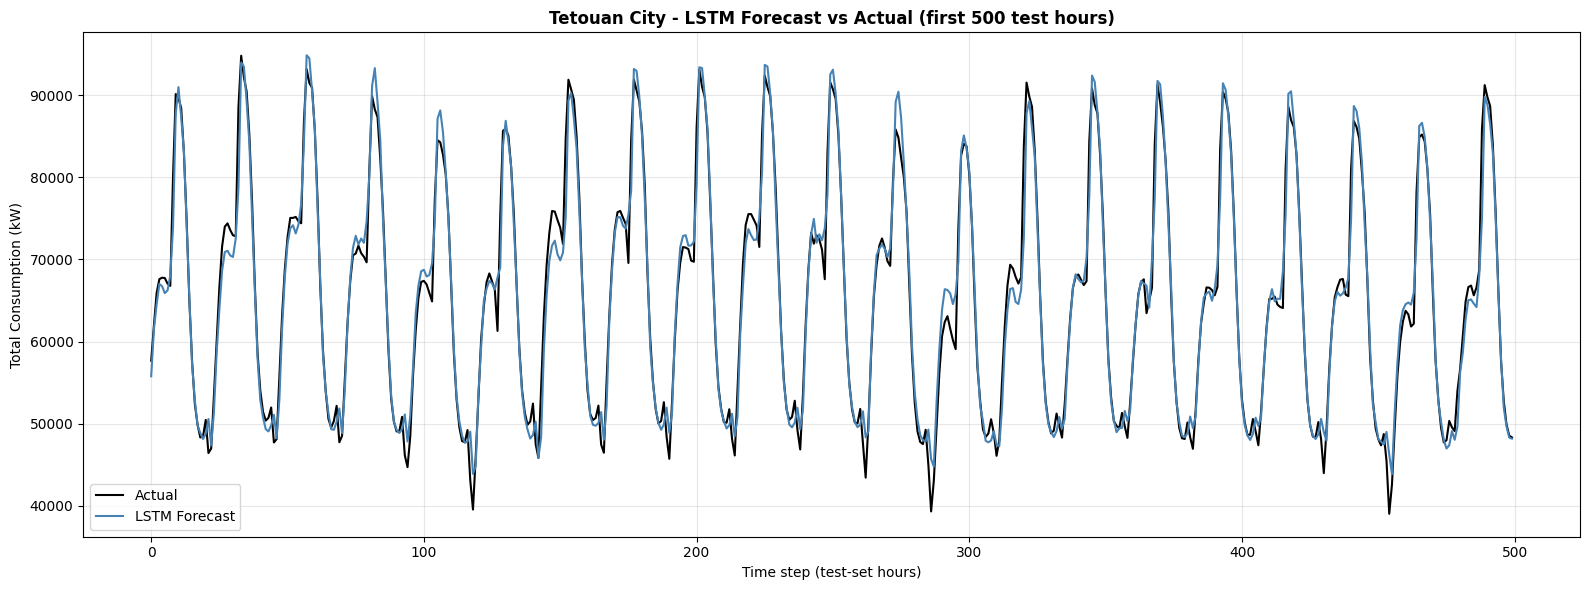

Saved graph + tetouan_predictions.csv


In [20]:
import matplotlib.pyplot as plt
import pandas as pd, os
os.makedirs('../results', exist_ok=True)

n = 500  # plot window, consistent with UCI

plt.figure(figsize=(16, 6))
plt.plot(y_true[:n], color='black', linewidth=1.5, label='Actual')
plt.plot(y_lstm[:n], color='steelblue', linewidth=1.5, label='LSTM Forecast')
plt.title('Tetouan City - LSTM Forecast vs Actual (first 500 test hours)', fontweight='bold')
plt.xlabel('Time step (test-set hours)'); plt.ylabel('Total Consumption (kW)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('../results/06_tetouan_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

pd.DataFrame({
    'Actual_kW': y_true[:n],
    'LSTM_Predicted_kW': y_lstm[:n],
    'Naive_Predicted_kW': y_naive[:n],
    'MA_Predicted_kW': y_ma[:n],
}).to_csv('../results/tetouan_predictions.csv', index=False)
print("Saved graph + tetouan_predictions.csv")

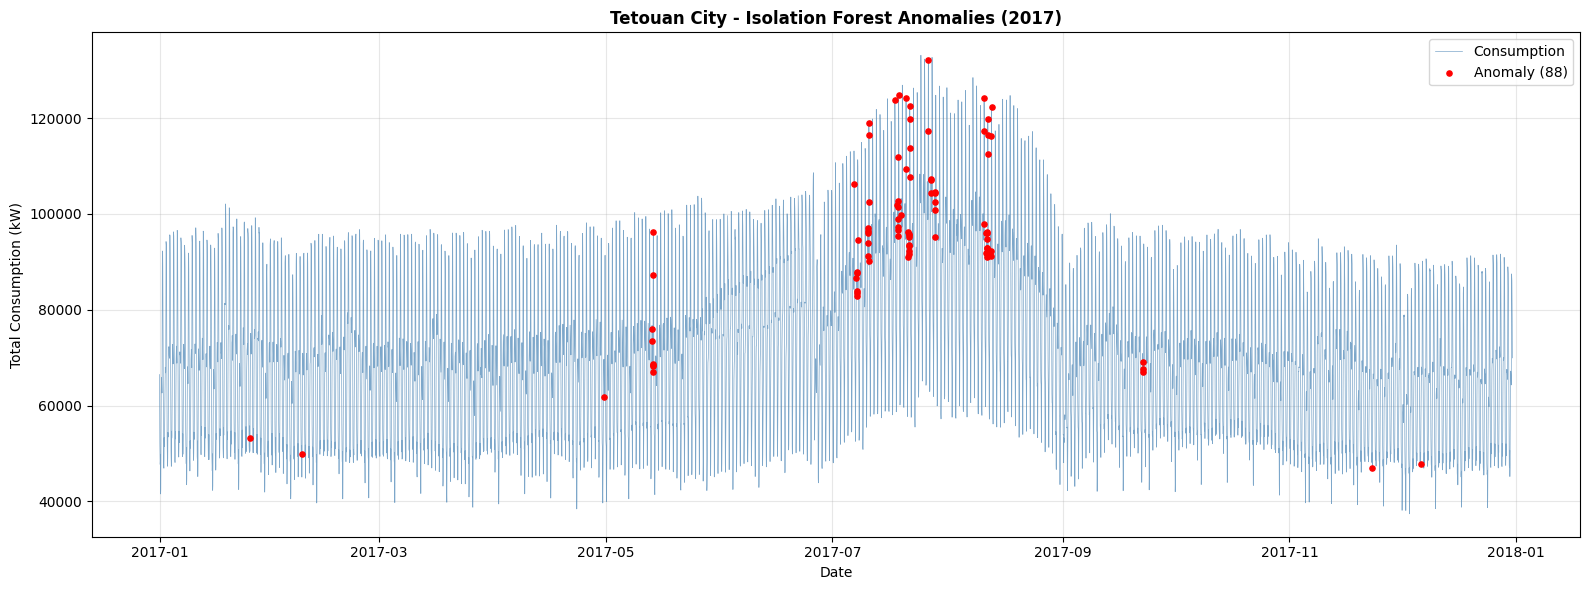

Saved anomaly graph + 88 anomalies + comparison CSV


In [21]:
plt.figure(figsize=(16, 6))
plt.plot(df_hourly.index, df_hourly['Total_Consumption'], color='steelblue',
         linewidth=0.5, alpha=0.7, label='Consumption')
plt.scatter(anoms.index, anoms['Total_Consumption'], color='red', s=14,
            zorder=5, label=f'Anomaly ({len(anoms)})')
plt.title('Tetouan City - Isolation Forest Anomalies (2017)', fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Total Consumption (kW)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('../results/07_tetouan_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

anoms.to_csv('../results/tetouan_detected_anomalies.csv')

pd.DataFrame({
    'Model': ['Naive', 'Moving Average', 'LSTM'],
    'MAE_kW': [4007.33, 11695.04, 1521.60],
    'RMSE_kW': [5465.53, 14034.60, 2299.07],
    'MAPE_pct': [6.24, 18.92, 2.41],
    'nMAE_pct': [6.21, 18.12, 2.36],
}).to_csv('../results/tetouan_model_comparison.csv', index=False)
print(f"Saved anomaly graph + {len(anoms)} anomalies + comparison CSV")